In [1]:
import os
import numpy as np
import bigfish
import bigfish.stack as stack
import bigfish.detection as detection
import bigfish.multistack as multistack
import bigfish.plot as plot
import pandas as pd
import matplotlib.pyplot as plt
from skimage import segmentation
from skimage.segmentation import find_boundaries
import matplotlib.patches as mpatches
from scipy import ndimage
from pathlib import Path
import psfmodels as psfm
from matplotlib.colors import PowerNorm
from sklearn.metrics import r2_score

In [2]:
# Change for your data
data = Path("/data/smfish/20260311_bartelle_smFISH_cryo_48hr_male")

In [3]:
# Load in image data 

# These tiffs are the registered, deconvolved, fused, 2D image
input_dir = data / "fused" / "all_tiles_2D"
path = os.path.join(input_dir, "fused_max_projected_bit005.ome.tiff")
rna = stack.read_image(path)
print("smfish channel")
print("\r shape: {0}".format(rna.shape))
print("\r dtype: {0}".format(rna.dtype))
print("\r nbytes: {0}".format(rna.nbytes))

# polyDT is our fiducial, or reference marker. This probe labels all polyadenylated RNA and is used for CellPose segmentation.
# We load in this data to visualize the cell boundaries.
polyDT_path = data / "fused"
path = os.path.join(polyDT_path, "fiducial_no_downsampling.ome.tiff")
polyDT_mip = stack.read_image(path)
print("polyDT channel")
print("\r shape: {0}".format(polyDT_mip.shape))
print("\r dtype: {0}".format(polyDT_mip.dtype))
print("\r nbytes: {0}".format(polyDT_mip.nbytes))

smfish channel
 shape: (27917, 22416)
 dtype: uint16
 nbytes: 1251574944
polyDT channel
 shape: (27917, 22416)
 dtype: uint16
 nbytes: 1251574944


In [ ]:
# stretch the contrast otherwise the spots will be dim and hard to see
polyDT_image_contrasted = stack.rescale(polyDT_mip, channel_to_stretch=0)

image_contrasted = stack.rescale(rna, channel_to_stretch=0)

In [4]:
# segmented cells
segmentation = data / "big_fish" / "segmentation"
path = os.path.join(segmentation, "fiducial_no_downsampling_masks.ome.tiff")
cell_label = stack.read_image(path)
print("segmented cells")
print("\r shape: {0}".format(cell_label.shape))
print("\r dtype: {0}".format(cell_label.dtype), "\n")

# detected spots
output_dir = data / "big_fish" / "results" / "all_tiles_2D"
spots_path = os.path.join(output_dir, "spots_bit_5.csv")
spots = pd.read_csv(spots_path, index_col=0, usecols=["spot_id", "y", "x", "bit"])
print("detected spots")
print("\r shape: {0}".format(spots.shape))
print(spots.head())

segmented cells
 shape: (27917, 22416)
 dtype: uint16 

detected spots
 shape: (20905, 3)
           y     x  bit
spot_id                
0        201  2568    5
1        354  2985    5
2        419  6190    5
3        419  6207    5
4        468  6946    5


# Visualize cell outlines over polyDT and readout images

In [ ]:
from scipy.ndimage import binary_dilation
from skimage.segmentation import find_boundaries

# Find cell boundaries at full resolution
boundaries = find_boundaries(cell_label, mode="outer")

# get original coordinates
H, W = polyDT_image_contrasted.shape

# Downsample for visualization only
ds = 8
polyDT_plot = polyDT_image_contrasted[::ds, ::ds]
boundaries_plot = boundaries[::ds, ::ds]

# Slightly thicken boundaries so they survive downsampling
boundaries = binary_dilation(boundaries, iterations=2)

print(polyDT_plot.shape)
# ~ (3490, 2802)

fig, ax = plt.subplots(figsize=(12, 10))

ax.imshow(
    polyDT_plot,
    cmap="gray",
    origin="upper",
    extent=[0, W, H, 0]
)

# Red transparent overlay containing only boundaries
overlay = np.zeros((*boundaries_plot.shape, 4), dtype=np.uint8)

overlay[boundaries_plot] = [255, 0, 0, 180]

ax.imshow(
    overlay,
    origin="upper",
    extent=[0, W, H, 0]
)

ax.set_title(
    "PolyDT fiducial channel with Cellpose segmentation masks",
    fontsize=14
)
ax.set_xlabel("X (pixels)")
ax.set_ylabel("Y (pixels)")

plt.tight_layout()
plt.show()

In [ ]:
## this took FOREVER. Ran for 50 minutes

# visuzalize the Cellpose segmentations on top of the polyDT channel

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the polyDT_mip image
ax.imshow(polyDT_image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
# asks Matplotlib to calculate contours corresponding to potentially thousands of individual values across a 626-million-pixel image
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

ax.set_title('PolyDT fiducial channel with Cellpose segmentation masks', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()

# Save as PDF
plt.savefig(
   segmentation / "cell_outlines_over_polyDT.pdf", 
   bbox_inches="tight")

# plt.show()

In [ ]:
# visuzalize the Cellpose segmentations on top of the Itgam channel

# Create figure and axes
fig, ax = plt.subplots(figsize=(12, 10))

# Display the Itgam channel image
ax.imshow(image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

ax.set_title('Itgam channel', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')

plt.tight_layout()
plt.show()

In [ ]:
# visualize the RNA channel with Cellpose segmentations and detected FISH spots

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 12))

# Display the contrast-enhanced Itgam channel image in grayscale
ax.imshow(image_contrasted, cmap='gray')

# Overlay the cellpose segmentation masks as outlines using contour
ax.contour(cell_label, levels=np.unique(cell_label)[1:], colors='red', linewidths=0.5, alpha=0.7)

# Overlay detected FISH spots
# spots has shape (nb_spots, 3) or (nb_spots, 2), for 3D or 2D images respectively.
# with the columns following the format (y, x) for 2D
spot_y = spots[:, 0]
spot_x = spots[:, 1]

# Plot detected spots as yellow circles (smaller size)
ax.scatter(spot_x, spot_y, c='yellow', s=10, marker='o', 
           edgecolors='white', linewidth=0.3, alpha=0.8, label='Detected spots')

ax.set_title('Itgam channel with Cellpose segmentation and detected FISH spots', fontsize=14)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Histograms

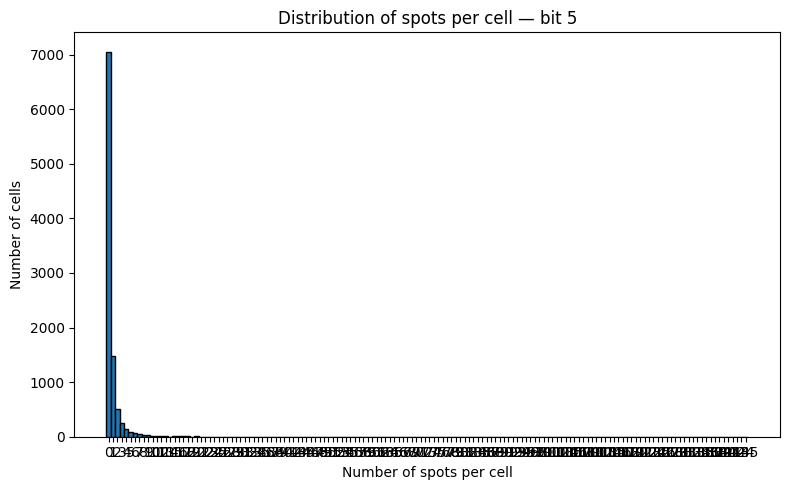

In [ ]:
def plot_spots_per_cell_histogram(spots, cell_label, bit):
    """Plot the distribution of detected spots per segmented cell for one bit."""

    bit_spots = spots[spots["bit"] == bit]

    # Convert spot coordinates to integer pixel indices
    y = bit_spots["y"].to_numpy(dtype=int)
    x = bit_spots["x"].to_numpy(dtype=int)

    # Keep only spots inside the image
    valid = (
        (y >= 0) & (y < cell_label.shape[0]) &
        (x >= 0) & (x < cell_label.shape[1])
    )

    spot_cell_ids = cell_label[y[valid], x[valid]]
    spot_cell_ids = spot_cell_ids[spot_cell_ids > 0]

    # Include cells with zero detected spots
    n_cells = int(cell_label.max())
    spots_per_cell = np.bincount(
        spot_cell_ids.astype(int),
        minlength=n_cells + 1
    )[1:]

    max_count = max(int(spots_per_cell.max()), 1)

    plt.figure(figsize=(8, 5))
    plt.hist(
        spots_per_cell,
        bins=np.arange(-0.5, max_count + 1.5, 1),
        edgecolor="black"
    )
    plt.xlabel("Number of spots per cell")
    plt.ylabel("Number of cells")
    plt.title(f"Distribution of spots per cell — bit {bit}")
    plt.xticks(range(max_count + 1))
    plt.tight_layout()

In [ ]:
# Generate and display one histogram per bit
for bit in sorted(spots["bit"].unique()):
    plot_spots_per_cell_histogram(spots, cell_label, bit)
    plt.show()

NameError: name 'max_count' is not defined